# Step 06 — Asset Returns by Regime

This notebook explores how each asset class performs within each market regime,
as computed by `pipelines/06_asset_returns.py`.

ETFs tracked: SPY (US equities), GLD (gold), TLT (long Treasuries),
USO (oil), QQQ (tech), IWM (small-cap), VNQ (real estate), AGG (bonds).

Key outputs:
- **Grouped bar chart** — median quarterly return per asset by regime
- **Heatmap** — compact view of returns (green = positive, red = negative)
- **Return distributions** — per-ticker histograms by regime
- **Ranking table** — best-to-worst asset within each regime

**Run `python pipelines/06_asset_returns.py` before executing this notebook.**

## Setup & Imports

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "../src")
import logging
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from market_regime.config import load, setup_logging
from market_regime.runtime import RunConfig
from market_regime import DATA_DIR, plotting
setup_logging("INFO")
log = logging.getLogger("06_assets")
cfg = load()
run_cfg = RunConfig(generate_plots=True, save_plots=True, show_plots=False)
REGIMES_DIR = DATA_DIR / "regimes"
RAW_DIR = DATA_DIR / "raw"

In [2]:
import subprocess
from pathlib import Path

def run_step_if_needed(step: int, required_paths: list, auto_run: bool = True) -> bool:
    """Run the pipeline step if any required output files are missing."""
    missing = [p for p in required_paths if not Path(p).exists()]
    if not missing:
        return True
    print(f"Missing: {[str(p) for p in missing]}")
    scripts = sorted(Path("../pipelines").glob(f"{step:02d}_*.py"))
    if not scripts:
        print(f"No pipeline script found for step {step}.")
        return False
    script = scripts[0]
    if not auto_run:
        print(f"  → Run: python {script}")
        return False
    print(f"  → Running {script.name} ...")
    result = subprocess.run(["python", str(script)], capture_output=True, text=True, cwd="..")
    out = result.stdout
    if len(out) > 4000:
        out = out[:2000] + "\n...\n" + out[-2000:]
    print(out)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-1000:])
        return False
    print(f"  ✓ Step {step} complete.")
    return True

# Run asset returns step if return profile is missing
run_step_if_needed(6, [REGIMES_DIR / "asset_return_profile.parquet"])

True

## Load Asset Return Profile

The return profile is a DataFrame with regimes as rows and assets as columns.
Cell values are median quarterly returns within each regime.

In [3]:
profile = None
labels = None
returns = None
regime_names = {}

# Asset return profile
try:
    profile = pd.read_parquet(REGIMES_DIR / "asset_return_profile.parquet")
    print(f"Asset return profile loaded: {profile.shape}")
    print(f"Assets: {list(profile.columns)}")
    print(f"Regimes: {list(profile.index)}")
except FileNotFoundError:
    print("ERROR: asset_return_profile.parquet not found. Run pipelines/06_asset_returns.py first.")
except Exception as exc:
    print(f"ERROR loading asset return profile: {exc}")

Asset return profile loaded: (5, 5)
Assets: ['10Y Treasury', 'GDP Growth', 'Inflation', 'S&P 500', 'S&P 500 Real']
Regimes: [0, 1, 2, 3, 4]


## Load Cluster Labels and Regime Names

In [4]:
# Cluster labels
try:
    labels_df = pd.read_parquet(REGIMES_DIR / "cluster_labels.parquet")
    label_col = "balanced_cluster" if "balanced_cluster" in labels_df.columns else "cluster"
    labels = labels_df[label_col]
    print(f"Labels loaded: {len(labels)} quarters (using '{label_col}')")
except FileNotFoundError:
    print("ERROR: cluster_labels.parquet not found. Run pipelines/03_cluster.py first.")

# Regime names
for names_path in [
    REGIMES_DIR / "regime_names_suggested.yaml",
    DATA_DIR.parent / "config" / "regime_labels.yaml",
]:
    try:
        with open(names_path) as f:
            raw_names = yaml.safe_load(f)
        regime_names = {int(k): str(v) for k, v in raw_names.items()}
        print(f"Regime names loaded from {names_path}")
        for k, v in sorted(regime_names.items()):
            print(f"  Regime {k}: {v}")
        break
    except FileNotFoundError:
        continue

if not regime_names and labels is not None:
    unique = sorted(labels.dropna().astype(int).unique())
    regime_names = {i: f"Regime {i}" for i in unique}
    print("Using generic regime names.")

# Raw quarterly asset prices / returns (for distribution plots)
try:
    returns = pd.read_parquet(RAW_DIR / "asset_prices.parquet")
    print(f"Asset prices loaded: {returns.shape}")
except FileNotFoundError:
    print("Note: asset_prices.parquet not found — distribution plots will be skipped.")
    print("Run pipelines/01_ingest.py to fetch ETF price history.")

Labels loaded: 304 quarters (using 'balanced_cluster')
Regime names loaded from /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../data/regimes/regime_names_suggested.yaml
  Regime 0: High Inflation / Rising CPI / Strong Growth
  Regime 1: Falling CPI / GDP Contracting / Rates Falling
  Regime 2: Rising CPI / Strong Growth / Strong Real Growth
  Regime 3: Falling CPI / Weak/Neg Growth / Weak Real Growth
  Regime 4: Low Inflation / Falling CPI / Strong Real Growth
Note: asset_prices.parquet not found — distribution plots will be skipped.
Run pipelines/01_ingest.py to fetch ETF price history.


## Asset Returns by Regime — Grouped Bar Chart

Median quarterly return per asset grouped by regime.
Positive bars indicate regimes where that asset typically outperforms.

2026-03-10 15:48:09 | INFO     | market_regime.plotting | Saved plot: /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../outputs/plots/06_asset_returns_by_regime.png


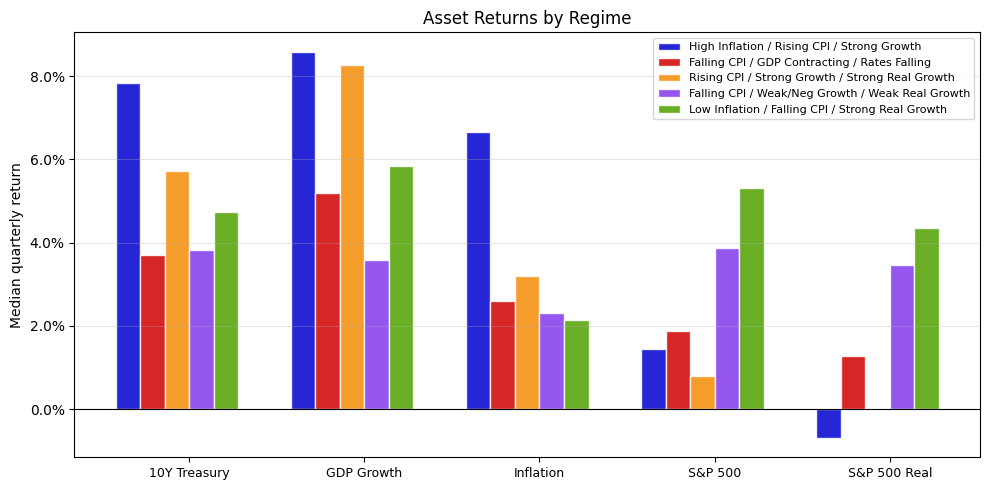

In [5]:
if profile is not None and not profile.empty:
    plotting.plot_asset_returns_by_regime(profile, regime_names, run_cfg)
elif profile is not None:
    print("Asset return profile is empty — nothing to plot.")

## Asset Returns Heatmap

Compact heatmap: regimes × assets.
Green cells indicate positive median returns; red cells indicate losses.

2026-03-10 15:48:10 | INFO     | market_regime.plotting | Saved plot: /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../outputs/plots/06_asset_heatmap.png


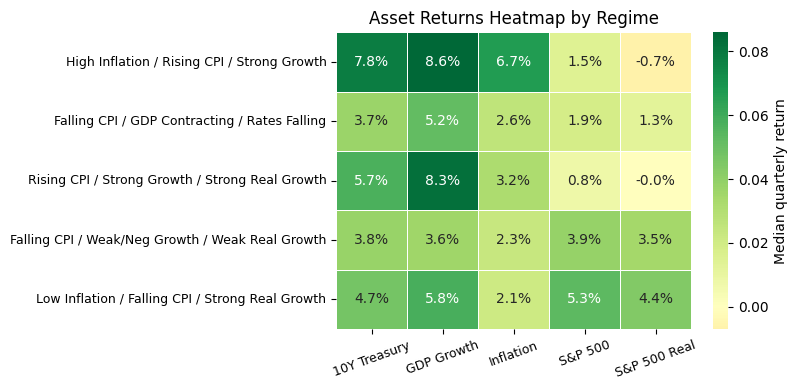

In [6]:
if profile is not None and not profile.empty:
    plotting.plot_asset_heatmap(profile, regime_names, run_cfg)
elif profile is not None:
    print("Asset return profile is empty — nothing to plot.")

## Return Distributions by Regime

Overlapping histograms of quarterly returns for each key ETF.
One distribution per regime — shows not just the median but the full
spread and tail risk within each regime.

In [7]:
TICKERS = ["SPY", "GLD", "TLT", "USO"]

if returns is not None and labels is not None:
    aligned_labels = labels.reindex(returns.index)
    for ticker in TICKERS:
        try:
            plotting.plot_asset_return_distributions(
                returns, aligned_labels, regime_names, ticker, run_cfg
            )
        except Exception as exc:
            print(f"Warning: could not plot distribution for {ticker}: {exc}")
else:
    print("Skipping distribution plots: asset prices or labels not loaded.")

Skipping distribution plots: asset prices or labels not loaded.


## Ranked Assets per Regime

For each regime: assets ranked from highest to lowest median quarterly return.
This is the core output used by the dashboard to generate buy/hold/sell signals.

In [12]:
if profile is not None and not profile.empty:
    print("Asset rankings by regime (median quarterly return, descending)")
    print("=" * 60)
    for rid in sorted(profile.index.astype(int).unique()):
        regime_row = profile.loc[rid].sort_values(ascending=False)
        name = regime_names.get(rid, f"Regime {rid}")
        print(f"\nRegime {rid} — {name}")
        print("-" * 40)
        for rank, (ticker, ret) in enumerate(regime_row.items(), start=1):
            direction = "BUY " if ret > 0.01 else ("SELL" if ret < -0.01 else "HOLD")
            print(f"  {rank:2d}. {ticker:<12} {ret:+7.2%}  [{direction}]")
else:
    print("No asset return profile available.")

Asset rankings by regime (median quarterly return, descending)

Regime 0 — High Inflation / Rising CPI / Strong Growth
----------------------------------------
   1. GDP Growth    +8.59%  [BUY ]
   2. 10Y Treasury  +7.83%  [BUY ]
   3. Inflation     +6.67%  [BUY ]
   4. S&P 500       +1.45%  [BUY ]
   5. S&P 500 Real  -0.70%  [HOLD]

Regime 1 — Falling CPI / GDP Contracting / Rates Falling
----------------------------------------
   1. GDP Growth    +5.19%  [BUY ]
   2. 10Y Treasury  +3.69%  [BUY ]
   3. Inflation     +2.60%  [BUY ]
   4. S&P 500       +1.88%  [BUY ]
   5. S&P 500 Real  +1.27%  [BUY ]

Regime 2 — Rising CPI / Strong Growth / Strong Real Growth
----------------------------------------
   1. GDP Growth    +8.28%  [BUY ]
   2. 10Y Treasury  +5.72%  [BUY ]
   3. Inflation     +3.19%  [BUY ]
   4. S&P 500       +0.80%  [HOLD]
   5. S&P 500 Real  -0.01%  [HOLD]

Regime 3 — Falling CPI / Weak/Neg Growth / Weak Real Growth
----------------------------------------
   1. S&P 500

## Full Return Profile Table

In [9]:
if profile is not None and not profile.empty:
    # Rename index to regime names for display
    display_profile = profile.copy()
    display_profile.index = [
        f"{i} — {regime_names.get(int(i), f'Regime {i}')}"
        for i in profile.index
    ]
    display(display_profile.style.format("{:.2%}").background_gradient(cmap="RdYlGn", axis=None))

,10Y Treasury,GDP Growth,Inflation,S&P 500,S&P 500 Real
0 — High Inflation / Rising CPI / Strong Growth,7.83%,8.59%,6.67%,1.45%,-0.70%
1 — Falling CPI / GDP Contracting / Rates Falling,3.69%,5.19%,2.60%,1.88%,1.27%
2 — Rising CPI / Strong Growth / Strong Real Growth,5.72%,8.28%,3.19%,0.80%,-0.01%
3 — Falling CPI / Weak/Neg Growth / Weak Real Growth,3.82%,3.58%,2.31%,3.87%,3.47%
4 — Low Inflation / Falling CPI / Strong Real Growth,4.72%,5.83%,2.14%,5.32%,4.35%
